In [81]:
import mne, os, glob, pickle
import numpy as np
import pandas as pd
import mne_rsa as rsa
import eelbrain
from mne.minimum_norm import apply_inverse_epochs
from scipy.spatial.distance import cosine
from gensim import downloader
import matplotlib

from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

# Set up

In [7]:
expt = 'SemRep'
main_dir = '/Volumes/Server/NEUROLING/Projects/SemRep'
mri_dir = os.path.join(main_dir, 'data','mri')
subjects =['R1441','R1701','R1834','R1954','R1974','R1985','R1993','R1994','R1998','R2029','R2031','R2041', 'R1830','R2149','R2021','R1439','R2148']
print(len(subjects))
parts = [1,2]

src = mne.setup_source_space(subject='fsaverage', spacing='ico4', subjects_dir=mri_dir)

17
Setting up the source space with the following parameters:

SUBJECTS_DIR = /Volumes/Server/NEUROLING/Projects/SemRep/data/mri
Subject      = fsaverage
Surface      = white
Icosahedron subdivision grade 4

>>> 1. Creating the source space...

Doing the icosahedral vertex picking...
Loading /Volumes/Server/NEUROLING/Projects/SemRep/data/mri/fsaverage/surf/lh.white...
Mapping lh fsaverage -> ico (4) ...
    Triangle neighbors and vertex normals...
Loading geometry from /Volumes/Server/NEUROLING/Projects/SemRep/data/mri/fsaverage/surf/lh.sphere...
Setting up the triangulation for the decimated surface...
loaded lh.white 2562/163842 selected to source space (ico = 4)

Loading /Volumes/Server/NEUROLING/Projects/SemRep/data/mri/fsaverage/surf/rh.white...
Mapping rh fsaverage -> ico (4) ...
    Triangle neighbors and vertex normals...
Loading geometry from /Volumes/Server/NEUROLING/Projects/SemRep/data/mri/fsaverage/surf/rh.sphere...
Setting up the triangulation for the decimated surface...

# Stats and fun plots 

## Create important variables

In [3]:
dirs = ["context+POS", "embeddings", "1hot","r2"] 
mods = ["contextsens",  "embedding",  "word", "w2vec"] 
colors = ['#E11466',"#EB3C6A","#F5646D","#F4753E","#F69D6B","#F7C497","#FBCE94","#FFD791"]
plotc = {mods[0]:'#E11466',mods[1]:"#FFD791",mods[2]:"#F4753E", mods[3]: "#A09BE7"} 

model_avgs = {}
model_res = {}
model_labels = {}

## Get the rsa results

Here we're going to extract the correlations from our pre-run stats and then plot the variance explained by each model

In [8]:
def get_model_data(direc, multiple):
    res_dir = os.path.join(main_dir,'data','analysis', 'RSA',direc)

    if multiple:
        modindex = idxdict[model]
    rsa_res, partlist = [],[]
    
    for subj in subjects:
            for part in parts:
                print(f'Beginning subject {subj} part {part}...')
                resfname = f'/{prefix[model]}results{subj}{suffix[model]}_part{part}.pickle'
                with open(res_dir + resfname, 'rb') as file:
                    subjrsa = pickle.load(file)
                if multiple:
                    subjrsa = subjrsa[modindex]
                    subjrsa
                rsa_res.append(subjrsa)
                partlist.append(part)
    print('Finished subject loop! \n')           
    return rsa_res, partlist

In [9]:
# loading in model specific vars
idxdict = {mods[0]:0, mods[2]:5} # which position on the pickle file each model was saved
prefix = {mods[0]: 'new-', mods[1]: '', mods[2]: '', mods[3]: 'w2v'}
suffix = {mods[0]: '', mods[1]: '', mods[2]: '-1hotmodels', mods[3]:''}

for index, model in enumerate(mods):
    # to choose the model from the list of models
    if index in [0,2]: # setting multiple so see if there are multiple results per file
        multiple = True
    elif index in [1,3]:
        multiple = False

    model = mods[index]
    direc = dirs[index]

    # launching the correlation extraction

    print(f'Loading the {model} model')
    rsa_res, partlist = get_model_data(direc, multiple)
    
    normalized_vals, subjectslist= [],[]

    for stc in rsa_res:

        # normalize using arctanh
        subj = stc.subject
        stc.data = np.arctanh(stc.data) 
        print(f'Morphing subject {subj}...')
        morph = mne.compute_source_morph(stc, subject_from=subj, subject_to='fsaverage', subjects_dir=mri_dir, spacing = 4)

        # morph to the fsaverage brain
        stc = morph.apply(stc)
        print(f'STCs morphed \n')
        
        normalized_vals.append(stc)
        subjectslist.append(subj)


    grand_avg = np.mean(np.array(normalized_vals),0) # calculate a subject grand average
    model_avgs[model]=grand_avg
    model_res[model]= np.array(normalized_vals)
    
    print('Done!')

Loading the contextsens model
Beginning subject R1441 part 1...
Beginning subject R1441 part 2...
Beginning subject R1701 part 1...
Beginning subject R1701 part 2...
Beginning subject R1834 part 1...
Beginning subject R1834 part 2...
Beginning subject R1954 part 1...
Beginning subject R1954 part 2...
Beginning subject R1974 part 1...
Beginning subject R1974 part 2...
Beginning subject R1985 part 1...
Beginning subject R1985 part 2...
Beginning subject R1993 part 1...
Beginning subject R1993 part 2...
Beginning subject R1994 part 1...
Beginning subject R1994 part 2...
Beginning subject R1998 part 1...
Beginning subject R1998 part 2...
Beginning subject R2029 part 1...
Beginning subject R2029 part 2...
Beginning subject R2031 part 1...
Beginning subject R2031 part 2...
Beginning subject R2041 part 1...
Beginning subject R2041 part 2...
Beginning subject R1830 part 1...
Beginning subject R1830 part 2...
Beginning subject R2149 part 1...
Beginning subject R2149 part 2...
Beginning subject 

In [11]:
model_avgs

{'contextsens': <SourceEstimate | 5124 vertices, subject : fsaverage, tmin : 0.0 (ms), tmax : 650.0 (ms), tstep : 2.0 (ms), data shape : (5124, 326), ~12.8 MiB>,
 'embedding': <SourceEstimate | 5124 vertices, subject : fsaverage, tmin : 0.0 (ms), tmax : 650.0 (ms), tstep : 2.0 (ms), data shape : (5124, 326), ~12.8 MiB>,
 'word': <SourceEstimate | 5124 vertices, subject : fsaverage, tmin : 20.0 (ms), tmax : 630.0 (ms), tstep : 2.0 (ms), data shape : (5124, 306), ~12.0 MiB>,
 'w2vec': <SourceEstimate | 5124 vertices, subject : fsaverage, tmin : 20.0 (ms), tmax : 580.0000000000001 (ms), tstep : 2.0 (ms), data shape : (5124, 281), ~11.0 MiB>}

The loop above loads in all of the data, normalized the stcs and averages them across participants. The easiest way to calculate statistics would be to run a one-sample t-test for each model and then control for multiple comparisons across models.

### Sample stats block

This is an example code block to run stats on one model. 
We're creating an eelbrain dataset and using the one sample t-test function. 
Normally this would be part of a larger loop through all of the models...

In [ ]:
model = 'embedding'

normalized_vals = model_res[model]

ds = e.Dataset()
ds['subject'] = e.Factor(subjectslist,random=True) # within subj
ds['part'] = e.Factor(partlist,random=True)
ds['src'] = e.load.fiff.stc_ndvar(normalized_vals, 'fsaverage', 'ico-4', mri_dir)

src = ds['src']
whole = src.sub(source=WB)
ds['srcm'] = whole
    
print('STCs subset to area of interest. Starting one sample t-test!')
    
res = e.testnd.TTestOneSample(ds['srcm'],
    ds=ds,
    pmin=0.05,  # threshold for clusters (uncorrected p-value)
    #tstart=0,  # start of the time window of interest
    #tstop=0.65,  # stop of the time window of interest
    mintime=0.04,  # minimum duration for clusters
    minsource=20,  # minimum number of sources for clusters
    match='subject')

Since I've already computed the stats, we're going to just load in the model results to subset the grand averages to the significant clusters only

## Get the stats results
This loads in the significant clusters across participants...

In [4]:
results = {} # collect the significant clusters to subset the data
model_times = {} # use this to determine the max time
# load the pickled results
for i, direc in enumerate(dirs):
    model = mods[i]
    res_dir = os.path.join(main_dir, 'data','analysis', 'RSA',direc)
    result_name = f'{model}-results-nomed.pickle'
    if model =='w2vec':
        result_name = f'Word2vec-results-nomed.pickle'

    with open(res_dir+f'/{result_name}' , 'rb') as f: # open the results
        res = pickle.load(f)
    results[model] = res

In [5]:
results

{'contextsens': <TTestOneSample 'srcm', match='subject', samples=10000, pmin=0.05, mintime=0.04, minsource=20, 34 clusters, p < .001>,
 'embedding': <TTestOneSample 'srcm', match='subject', samples=10000, pmin=0.05, mintime=0.04, minsource=20, 42 clusters, p = .003>,
 'word': <TTestOneSample 'srcm', match='subject', samples=10000, pmin=0.05, mintime=0.04, minsource=20, 31 clusters, p = .031>,
 'w2vec': <TTestOneSample 'srcm', match='subject', samples=10000, pmin=0.05, mintime=0.04, minsource=20, 40 clusters, p = .008>}

Below is just a small loop to get the maximum times of each cluster in order to plot them all together...

In [55]:
for model in mods:
    # get time info from MNE
    clu =  get_clusters(results[model], mri_dir)[0]
    times  = get_MNE_cluster(clu, False).times
    model_times[model]= times

cluster 1: lh
cluster 1: lh
cluster 1: lh
cluster 1: rh


## More helper functions

We need these to square the correlations and create custom labels for the results!

In [71]:
def get_clusters(res, mri_dir):
    ''' Function that returns the significant clusters and specifies which hemisphere each one represents
    res: eelbrain anova results file
    '''
    mask_sign_clusters = np.where(res.clusters['p'] <= 0.05, True, False)
    sig_clusters = res.clusters[mask_sign_clusters]
    # maybe add a print statement to tell me how many there are?; and adapt to loop
    cluster = sig_clusters[0]
    clu = cluster['cluster']
    eelbrain.load.update_subjects_dir(clu, mri_dir)
    clu = eelbrain.complete_source_space(clu)
    hemi = cluster['hemi']

    print(f'cluster 1: {hemi}')

    if len(sig_clusters['cluster']) > 1: # if more than one cluster in the results then combine them
        cluster2 = sig_clusters[1]
        clu2 = cluster2['cluster']
        clu2 = e.complete_source_space(clu2)
        hemi2 = cluster2['hemi']
        print(f'cluster 2: {hemi2}')
        comb = clu + clu2

    return comb if len(sig_clusters['cluster']) > 1 else (clu, hemi)

def get_MNE_cluster(cluster, get_brain=True, views = ['lat', 'med'],initial_time=0.1,**kwargs):
     '''Function for transforming eelbrain clusters into MNE ones
     Get_brain: True returns the brain object; False returns the MNE cluster for more manipulation
     '''
     vertices = fsave_vertices = [np.arange(2562), np.arange(2562)]

     if 'tmin' in kwargs.keys(): # start time for stc
         tmin = kwargs['tmin']
     else:
         tmin = 0
     data = cluster.get_data(['source', 'time'])
     tstep = 0.002 # sampling rate; change this to reflect data

     stc = mne.SourceEstimate(data, vertices,tmin, tstep)
     if get_brain: # if plotting directly define the hemiphere
         if 'hemi' in kwargs.keys():
             hemi = kwargs['hemi']
         else:
             hemi = 'lh'
         brain = plot_MNE_brain(stc,views, mri_dir,initial_time=initial_time, hemi=hemi)
         return brain
     else:
         return stc

def plot_MNE_brain(stc, views, mri_dir,initial_time=0.1, hemi='lh', colormap=None, annot=True, **kwargs):
     ''' Plotting function that takes an stc and makes pretty plots with the settings I like
     clim: sets the limits of the color range to have uniform brains
     view_layout: horizontal or vertical
     colorbar: True or False
     annot: True or False
     '''

     peak_vertex, peak_time = stc.get_peak(vert_as_index=True)
     if 'clim' in kwargs.keys(): # set the limits if defined
         clim = kwargs['clim']
     else:
         clim='auto' # automatic color limits
     if 'view_layout' in kwargs.keys(): # to set horizontal or not
         view_layout = kwargs['view_layout']
         if view_layout == 'horizontal':
             size = (800, 400)
     else:
         view_layout='vertical'
         size = 800
     if 'colorbar' in kwargs.keys(): # turn the colorbar on or off
         colorbar = kwargs['colorbar']
     else:
         colorbar= True
     brain = stc.plot('fsaverage',subjects_dir=mri_dir, initial_time=initial_time, surface = 'smoothwm', cortex = 'low_contrast', background='white', hemi = hemi,  views= views, colormap = colormap, clim=clim, view_layout = view_layout, colorbar=colorbar, size = size)
     if annot:
        brain.add_annotation('aparc',alpha=0.7, color= 'white')
     return brain


def create_model_label(res,mri_dir,src):
    '''
    Creates stc label from eelbrain cluster
    '''
    clu =  get_clusters(res, mri_dir)[0]
    stc = get_MNE_cluster(clu, False)

    # create label from stc mean activity
    func_label = mne.stc_to_label(
        stc,
        src=src,
        smooth = False,
        subjects_dir=mri_dir,
        connected=False,
        verbose="error",
    )
    mask = [ func for func in func_label if func!=None ]
    label = mask[0]
    
    return label

The first step is to get the eelbrain cluster and transform it into a more flexible MNE format

In [59]:
model = 'embedding'
res = results[model]
clu =  get_clusters(res, mri_dir)[0]
clu

cluster 1: lh


<NDVar 'cluster': 5124 source, 326 time>

Now we transform it with a custom function

In [77]:
stc = get_MNE_cluster(clu, False)
stc.plot('fsaverage',subjects_dir=mri_dir, surface = 'smoothwm', cortex = 'low_contrast', background='white', hemi = 'lh',  views= ['lat','med'])

FileNotFoundError: [Errno 2] No such file or directory

In [ ]:
def create_var_timecourse(stc, res, mri_dir, src):
    func_label = create_model_label(res,mri_dir,src) # make functional label
    # get data and transform it
    newstc = stc.in_label(func_label)
    # square the correlations to get the variance explained
    newstc.data = newstc.data**2

    timecourse = newstc.extract_label_time_course(func_label, src, mode='mean')[0]
    return timecourse

The function above gets the significant clusters from the eelbrain tests, transforms them into MNE stcs, and creates a label or functional mask from the significant vertices. We need this to subset the variance down to these vertices!

Getting contextsens model...
cluster 1: lh
Extracting time courses for 1 labels (mode: mean)
This is how long the timecourse is: 326
Getting embedding model...
cluster 1: lh
Extracting time courses for 1 labels (mode: mean)
This is how long the timecourse is: 326
Getting word model...
cluster 1: lh
Extracting time courses for 1 labels (mode: mean)
This is how long the timecourse is: 306
The timecourse is shorter than the timewindow of interest. Padding timecourse...
Getting w2vec model...
cluster 1: rh
Extracting time courses for 1 labels (mode: mean)
This is how long the timecourse is: 281
The timecourse is shorter than the timewindow of interest. Padding timecourse...


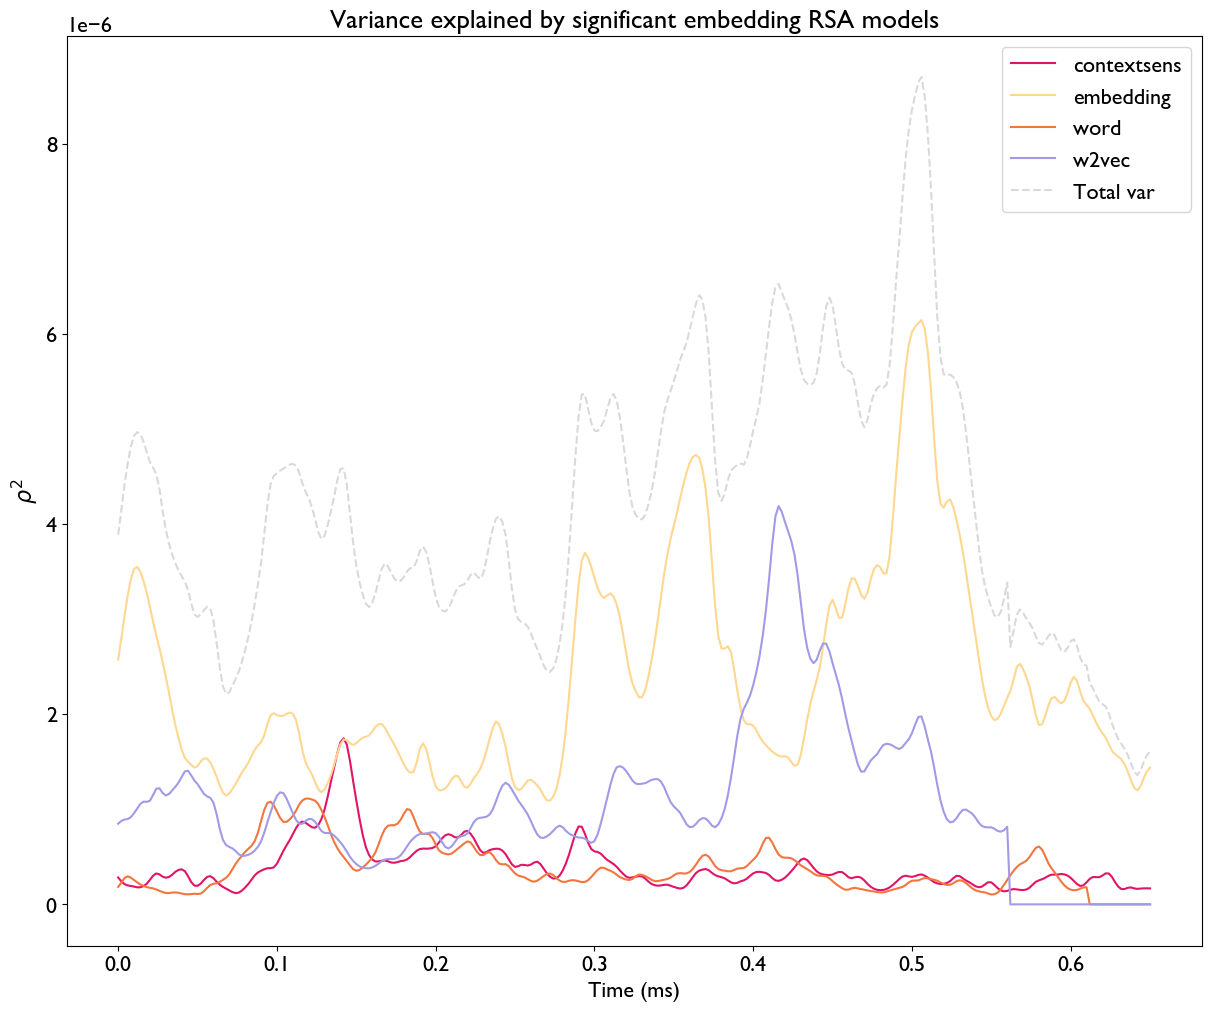

In [56]:
fig = plt.figure(figsize = [6,5])
matplotlib.rcParams.update({'font.size': 16})
matplotlib.rcParams["font.family"] = "Gill Sans"
times = model_times["embedding"]

total = 0
for model,res in results.items():
    print(f"Getting {model} model...")
    stc = model_avgs[model]
    timecourse = create_var_timecourse(stc,res,mri_dir,src)
    t_len = len(timecourse)
    print(f'This is how long the timecourse is: {t_len}')
    if t_len<len(times):
        print('The timecourse is shorter than the timewindow of interest. Padding timecourse...')
        modtimecourse = np.pad(timecourse, (0, len(times) - t_len), mode='constant', constant_values=0)
        timecourse = modtimecourse
    plt.plot(times, timecourse, plotc[model], label = model)
    total+= timecourse

plt.plot(times, total, '--k', label = 'Total var', alpha = 0.15)
plt.legend()
plt.xlabel('Time (ms)')
plt.ylabel(r'$\rho^2$')
plt.title('Variance explained by significant embedding RSA models')
fig.set_constrained_layout(True)